# **Build a Multi-Modal Generation Agent**

In [ ]:
import os
from huggingface_hub import login

login(token=os.environ["HF_TOKEN"])

In [ ]:
import torch, diffusers, transformers, os, random, gc
print('torch', torch.__version__, '| CUDA:', torch.cuda.is_available())

torch 2.10.0+cu128 | CUDA: True


## 2. Text-to-Image

In [ ]:
from diffusers import DiffusionPipeline

model_id = 'stabilityai/stable-diffusion-xl-base-1.0'
# Use torch_dtype=torch.float16 to ensure consistent half-precision computation on GPU
pipe_img = DiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, variant='fp16')\
    .to('cuda' if torch.cuda.is_available() else 'cpu')
pipe_img.enable_attention_slicing()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


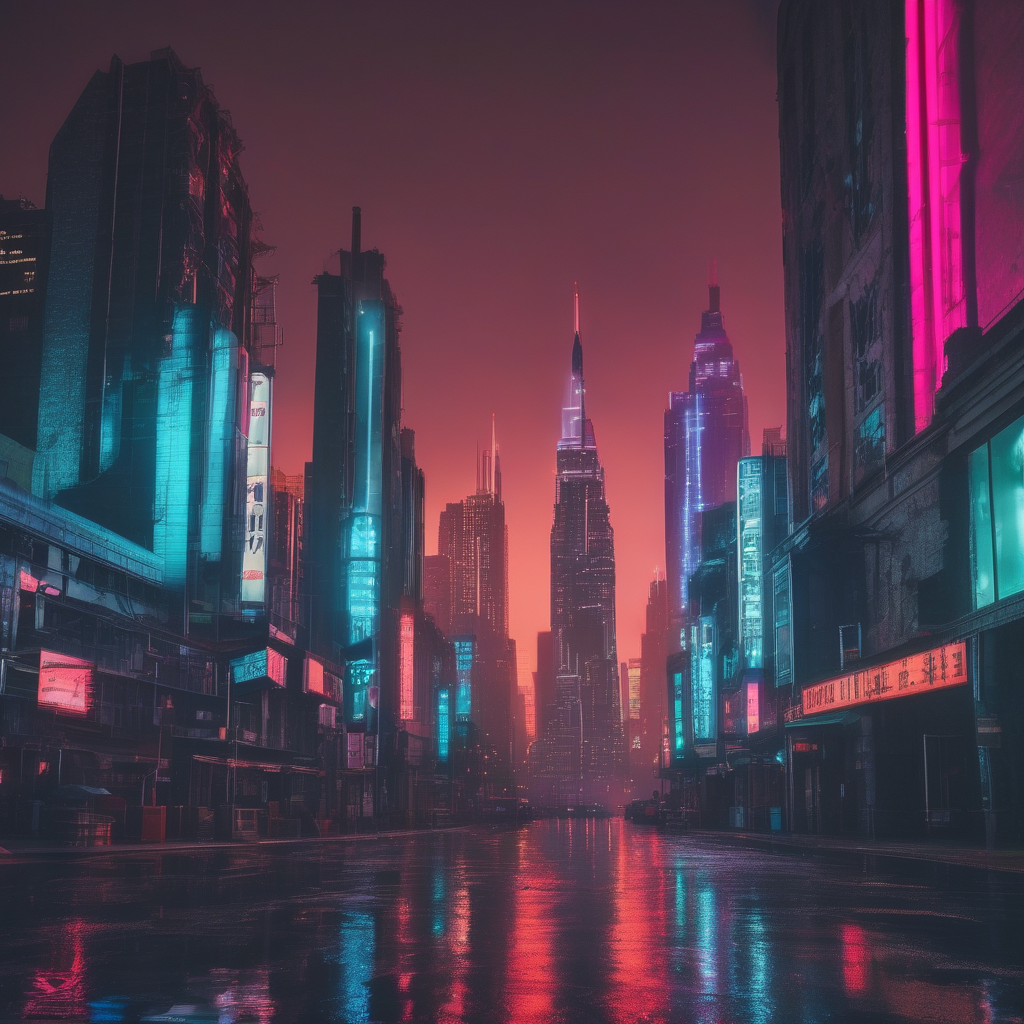

In [ ]:
# Generate and display an image from a text prompt using the loaded pipline

prompt = 'cinematic photograph of a futuristic neon futuristic Gotham City \
          at dusk, 35mm lens'
image = pipe_img(prompt).images[0]
image

### 2.1 Experimenting with "Inference_steps"

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

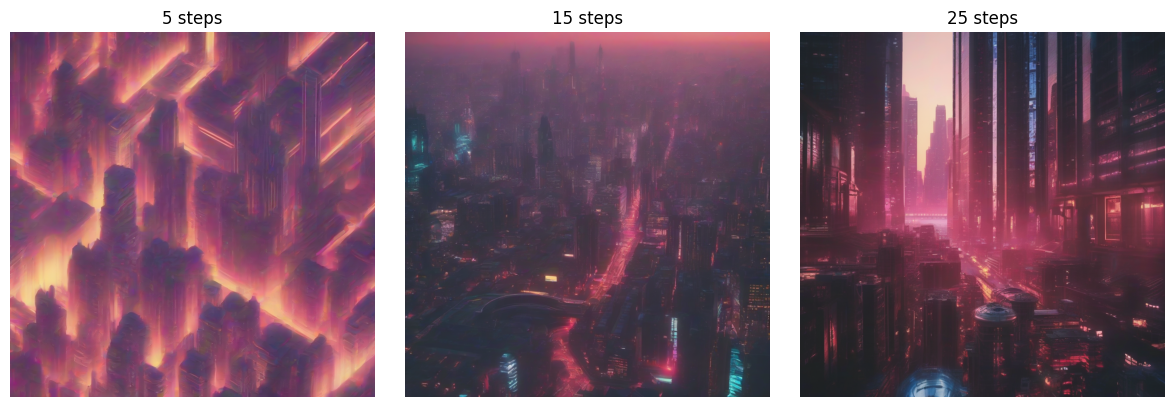

In [ ]:
import matplotlib.pyplot as plt

images = []

prompt = 'cinematic photograph of a futuristic neon futuristic Gotham City \
          at dusk, 35mm lens'

steps_list = [5, 15, 25]
for steps in steps_list:
  image = pipe_img(prompt=prompt, num_inference_steps=steps).images[0]
  images.append((steps, image))

# Plot results side-by-side
plt.figure(figsize=(12, 4))
for i, (steps, img) in enumerate(images, 1):
    plt.subplot(1, len(images), i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{steps} steps")
plt.tight_layout()
plt.show()

## 2.2 (Optional) other possible ways:

-Visualizing the Diffusion Process
Diffusion models start from random noise and iteratively refine it into an image that matches the prompt. If you are curious, visualize all intermediate steps to see how the noise gradually turns into a coherent picture.

-Experiment with other models.
Different text-to-image models vary in speed, style, and visual quality. Try swapping in other open-source diffusion models and compare how their outputs differ in detail, realism, or artistic tone.

You can browse available models on Hugging Face here: https://huggingface.co/models?library=diffusers

## 3. Text-to-Video

In [ ]:
from diffusers import DiffusionPipeline, DPMSolverMultistepScheduler

video_model_id = 'damo-vilab/text-to-video-ms-1.7b'

# Load the model with FP16 precision for efficiency
pipe_vid = DiffusionPipeline.from_pretrained(video_model_id, torch_dtype=torch.float16, variant="fp16")
pipe_vid.scheduler = DPMSolverMultistepScheduler.from_config(pipe_vid.scheduler.config)
pipe_vid.enable_model_cpu_offload()

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

The TextToVideoSDPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


In [ ]:
# Write a text prompt describing the video we want to generate
# Run the text-to-video pipline with our chosen prompt

prompt = "Batman is checking Gotham City"
vid_frams = pipe_vid(prompt=prompt, num_inference_steps=25).frames[0]
print(vid_frams.shape)

  0%|          | 0/25 [00:00<?, ?it/s]

(16, 256, 256, 3)


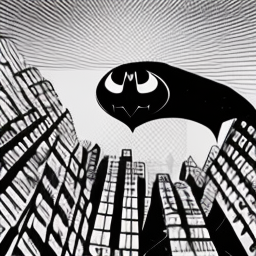

In [ ]:
# Frame inspection
import numpy as np
from PIL import Image

Image.fromarray((vid_frams[0] * 255).astype(np.uint8))

In [ ]:
# Convert frames to MP4
from diffusers.utils import export_to_video

video_path = export_to_video(vid_frams)
video_path

'/tmp/tmprksp6xfo.mp4'

In [ ]:
# Display the saved MP4 inline
from IPython.display import Video

Video(video_path, embed=True)

# 4. Multimodal Generation Agent

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch, textwrap, json, re

# Load google/gemma-3-1b-it using Hugging Face
model_id = "google/gemma-3-1b-it"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)
gemma_llm = pipeline("text-generation", model=model, tokenizer=tokenizer)

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

In [ ]:
def generate_media(prompt: str, mode: str):
    # Produce either an image or a short video clip from a text prompt.
    if mode == 'image':
        return pipe_img(prompt).images[0]
    else:
        frames = pipe_vid(prompt, num_frames=16, num_inference_steps=25).frames
        return frames[0]

def llm_generate(prompt, max_new_tokens=64, temperature=0.7):
    # Return a response to the prompt with the loaded gemma
    outputs = gemma_llm(prompt, max_new_tokens=max_new_tokens, do_sample=True, temperature=temperature)
    return outputs[0][0]["generated_text"][-1]["content"]

In [ ]:
def classify_prompt(prompt: str):
    """Classify the user prompt into QA, image, or video."""

    # Step 1: Define a system prompt explaining how to classify requests (qa, image, video)
    # Step 2: Format the user message and system message as input to the LLM
    # Step 3: Generate a response with llm_generate() and parse it using regex
    # Step 4: Extract fields "type" and "expanded_prompt" from the LLM response
    # Step 5: Return a dict with classification results or default to {"type": "qa"} on failure
    system = textwrap.dedent("""You are a routing assistant for a multimodal generation system.
        Decide whether the USER request is:
          • a factual or conversational question  →  type = "qa"
          • an IMAGE generation request          →  type = "image"
          • a VIDEO generation request           →  type = "video"
        If it is for image or video, produce an improved, vivid, detailed `expanded_prompt`.
        Respond ONLY in this format: {"type": "...", "expanded_prompt": "..."}
    """)

    messages = [
      [
          {
              "role": "system",
              "content": [{"type": "text", "text": system},]
          },
          {
              "role": "user",
              "content": [{"type": "text", "text": prompt},]
          },
      ],
    ]
    response = llm_generate(messages, temperature=0.2)
    match = re.search(r'"type"\s*:\s*"([^"]+)"\s*,\s*"expanded_prompt"\s*:\s*"([^"]+)', response)
    if match:
        try:
            result = {
              "type": match.group(1),
              "expanded_prompt": match.group(2)
            }
            return result
        except Exception:
            pass
    # fallback
    return {"type": "qa"}

In [ ]:
def multimodal_agent(user_prompt: str):
    # Step 1: Classify the request
    # Step 2: Route the prompt and generate output
    decision = classify_prompt(user_prompt)
    kind = decision.get('type', 'qa')
    if kind == 'qa':
        system = "You are a helpful assistant."
        messages = [
            [
                {
                    "role": "system",
                    "content": [{"type": "text", "text": system},]
                },
                {
                    "role": "user",
                    "content": [{"type": "text", "text": user_prompt},]
                },
            ],
        ]
        return llm_generate(messages)
    else:
        return generate_media(decision['expanded_prompt'], mode=kind)

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GemmaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_


PROMPT: What's the capital of Sweden?
The capital of Sweden is Stockholm. 😊


  0%|          | 0/50 [00:00<?, ?it/s]


PROMPT: Generate an image of a neon dragon in cartons style flying over Tokyo at night


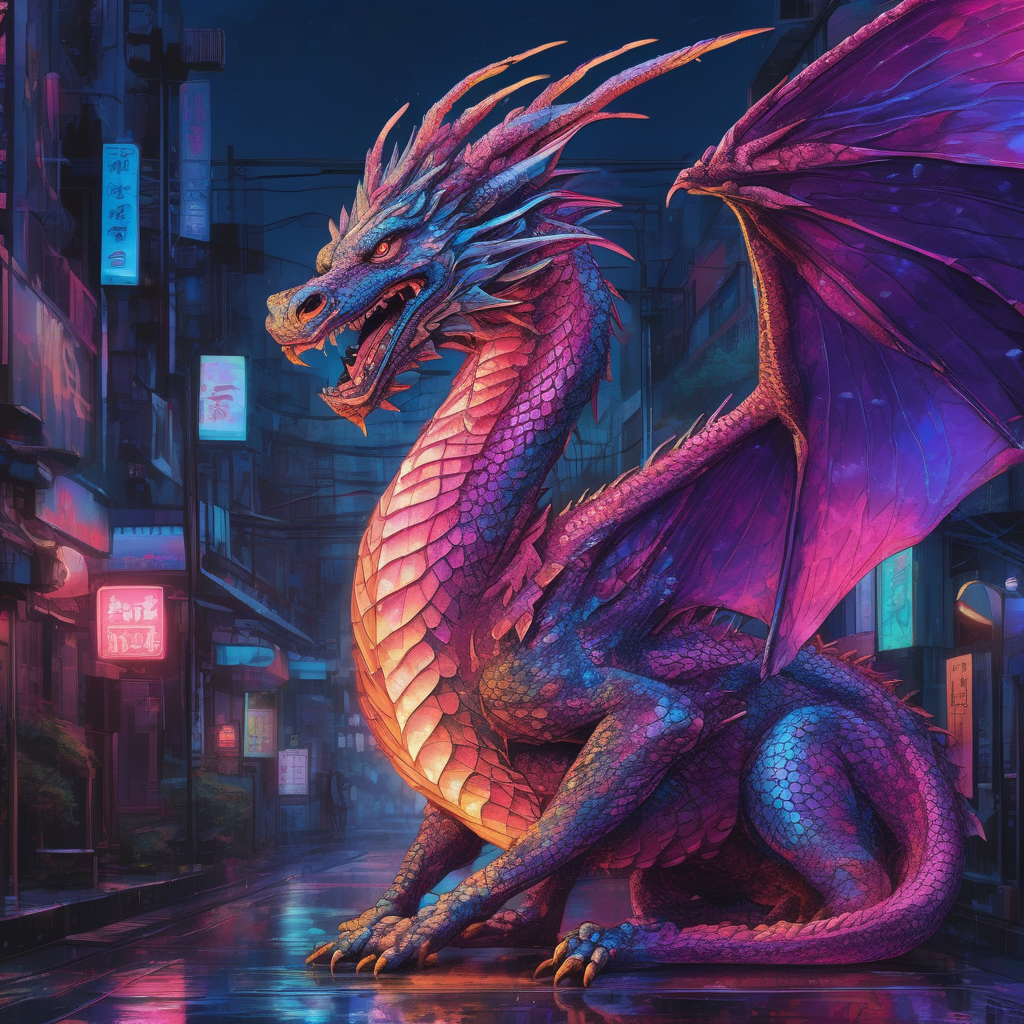

[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  0%|          | 0/25 [00:00<?, ?it/s]


PROMPT: Create a short video of a paper plane folding itself
video path: /tmp/tmpnlnkxtfl.mp4


In [ ]:
from diffusers.utils import export_to_video
from IPython.display import display, Video

# Step 1: Define a few diverse prompts (QA, image, video)
# Step 2: For each prompt, call multimodal_agent and inspect the returned result
for p in [
    "What's the capital of Sweden?",
    "Generate an image of a neon dragon in cartons style flying over Tokyo at night",
    "Create a short video of a paper plane folding itself"
]:
    result = multimodal_agent(p)
    print('\nPROMPT:', p)
    if isinstance(result, str):
        print(result)
    else:
        if hasattr(result, 'save'):
            display(result)
        else:
            vid = export_to_video(result)
            print(f"video path: {vid}")
            display(Video(vid, embed=True))

In [ ]:
import gradio as gr
with gr.Blocks() as demo:
    gr.Markdown('# Multimodal Agent')
    inp = gr.Textbox(placeholder='Ask or create...')
    btn = gr.Button('Submit')
    out_text = gr.Markdown()
    out_img = gr.Image()
    out_vid = gr.Video()

    def handle(prompt):
        res = multimodal_agent(prompt)
        if isinstance(res, str):
            return res, None, None
        elif hasattr(res, 'save'):
            return '', res, None
        else:
            vid = export_to_video(res)
            return '', None, vid

    btn.click(handle, inp, [out_text, out_img, out_vid])

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b5572d5973cb23eee9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
